# Maribel Ramirez Gaviria
# Jaider Andrés Cataño Ospina

# Introducción

El fútbol es uno de los deportes más populares y competitivos del mundo, y la Copa Mundial de la FIFA representa el torneo más importante a nivel de selecciones nacionales. Debido a la gran cantidad de variables que influyen en el desempeño de los equipos, el análisis de datos y las técnicas de Machine Learning permiten estudiar patrones históricos y generar modelos predictivos capaces de anticipar resultados deportivos.

En este proyecto se busca desarrollar un modelo predictivo que permita estimar la probabilidad de que una selección nacional alcance los cuartos de final de la Copa Mundial de la FIFA. Para ello, se utilizará información histórica y estadística de los equipos participantes, considerando variables relacionadas con rendimiento deportivo, experiencia internacional, ranking FIFA, desempeño ofensivo y defensivo, historial en mundiales anteriores y valor de mercado de las plantillas.

El objetivo principal es identificar cuáles factores tienen mayor influencia en el éxito de una selección y utilizar esta información para construir un modelo de clasificación supervisada que permita predecir si un equipo logrará llegar a los cuartos de final del torneo.

Este análisis resulta interesante porque combina conocimientos de analítica deportiva, estadística y aprendizaje automático para transformar datos históricos en información predictiva útil.

# Descripción del Dataset

El dataset utilizado contiene información histórica y estadística de selecciones nacionales participantes en distintas ediciones de la Copa Mundial de la FIFA, desde el 2006 hasta la fecha. Cada registro representa el desempeño y características de un equipo antes del inicio de un torneo.

A continuación, se describen las principales variables del conjunto de datos:

| Columna | Descripción |
|---|---|
| version | Edición o año de la Copa Mundial de la FIFA correspondiente al registro. |
| team | Selección nacional participante en la Copa Mundial. |
| continent | Continente al que pertenece la selección nacional. |
| is_host | Indica si el equipo fue anfitrión del torneo. |
| goals_scored_last_4_years | Total de goles anotados por el equipo durante los cuatro años previos al Mundial. |
| goals_conceded_last_4_years | Total de goles recibidos por el equipo durante los cuatro años previos al Mundial. |
| wins_last_4_years | Cantidad de partidos ganados por la selección en los cuatro años anteriores al torneo. |
| losses_last_4_years | Cantidad de partidos perdidos por la selección en los cuatro años anteriores al torneo. |
| draws_last_4_years | Cantidad de partidos empatados por la selección en los cuatro años anteriores al torneo. |
| world_cup_titles_before | Número de títulos de Copa Mundial obtenidos por el equipo antes de esa edición. |
| squad_market_value_eur | Valor de mercado total estimado de la plantilla del equipo en euros. |
| fifa_rank_pre_tournament | Posición del equipo en el ranking FIFA antes del torneo. |
| fifa_points_pre_tournament | Puntos FIFA acumulados por el equipo antes del torneo. |
| squad_average_age | Edad promedio de la plantilla de jugadores. |
| previous_world_cup_appearances | Número de participaciones previas en Copas Mundiales antes de esa edición. |
| group_stage_passed_before | Número de veces que el equipo superó la fase de grupos anteriormente. |
| round16_before | Número de veces que el equipo alcanzó los octavos de final anteriormente. |
| quarterfinals_before | Número de veces que el equipo alcanzó los cuartos de final anteriormente. |
| semifinals_before | Número de veces que el equipo alcanzó las semifinales anteriormente. |
| finals_before | Número de veces que el equipo llegó a la final anteriormente. |
| winner | Indica si el equipo ganó la Copa Mundial en esa edición. |
| finalist | Indica si el equipo llegó a la final. |
| semifinalist | Indica si el equipo alcanzó las semifinales. |
| quarterfinalist | Indica si el equipo alcanzó los cuartos de final. |

# Variable Objetivo

La variable objetivo seleccionada para el modelo predictivo será:

```python
quarterfinalist
```

Esta variable permitirá entrenar un modelo de clasificación supervisada para estimar la probabilidad de que una selección nacional logre llegar a los cuartos de final de la Copa Mundial de la FIFA.

# 1. Importación de las bases de datos

## 1.1 librerias

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import shap
import lime
import lime.lime_tabular
import warnings
warnings.filterwarnings("ignore")

## 1.2 Importación de los datos

En este caso los datos se importan de Kaggle vía API. Se importan dos bases de datos una llamada train y otra llamada test (esta no es una base de datos para prueba del modelo si no que contiene lo que se desea predecir que es sobtre el mundial 2026), ya que así estan estructuradas por la página.

In [ ]:
# Importamos la data de entrenamiento

import kagglehub 
from kagglehub import KaggleDatasetAdapter

file_path = "train.csv"

df_train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "harrachimustapha/fifa-world-cup-team-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_train.head().sort_index()

100%|██████████| 16.1k/16.1k [00:00<00:00, 20.6MB/s]


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2006,Angola,Africa,0,61,49,19,13,14,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,Argentina,South America,0,97,55,31,10,10,2,...,13,10,5,6,4,4,0,0,0,1
2,2006,Australia,Oceania,0,101,34,23,8,5,0,...,1,0,0,0,0,0,0,0,0,0
3,2006,Brazil,South America,0,117,47,30,9,17,5,...,17,15,7,11,9,6,0,0,0,1
4,2006,Costa Rica,North America,0,89,84,26,25,11,0,...,2,1,1,0,0,0,0,0,0,0


In [ ]:
# Importamos la data de prueba
file_path = "test.csv"

df_test = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "harrachimustapha/fifa-world-cup-team-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df_test.head()

Using Colab cache for faster access to the 'fifa-world-cup-team-dataset' dataset.


,version,team,continent,is_host,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,world_cup_titles_before,...,world_cup_participations_before,groups_passed_before,round16_before,quarterfinals_before,semifinals_before,finals_before,winner,finalist,semi_finalist,quarter_finalist
0,2026,France,Europe,0,85,32,25,6,7,2,...,16,10,8,9,7,4,NaN,NaN,NaN,NaN
1,2026,Spain,Europe,0,104,32,29,2,8,1,...,16,11,9,6,2,1,NaN,NaN,NaN,NaN
2,2026,Argentina,South America,0,80,14,30,4,3,3,...,18,15,10,10,6,6,NaN,NaN,NaN,NaN
3,2026,England,Europe,0,82,23,26,6,7,1,...,16,13,8,10,3,1,NaN,NaN,NaN,NaN
4,2026,Portugal,Europe,0,98,31,26,5,7,0,...,8,5,4,3,2,0,NaN,NaN,NaN,NaN


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192 entries, 0 to 191
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   version                          192 non-null    int64  
 1   team                             192 non-null    object 
 2   continent                        192 non-null    object 
 3   is_host                          192 non-null    int64  
 4   goals_scored_last_4y             192 non-null    int64  
 5   goals_received_last_4y           192 non-null    int64  
 6   wins_last_4y                     192 non-null    int64  
 7   losses_last_4y                   192 non-null    int64  
 8   draws_last_4y                    192 non-null    int64  
 9   world_cup_titles_before          192 non-null    int64  
 10  squad_total_market_value_eur     160 non-null    float64
 11  fifa_rank_pre_tournament         192 non-null    int64  
 12  fifa_points_pre_tourna

Se tiene 3 datos flotantes, 19 enteros y 2 strings para un total de 24 variables

# 2. Análisis exploratorio

Validamos la cantidad de datos de entrenamiento y prueba que se tienen.

In [ ]:
print("Tamaño train:", df_train.shape)
print("Tamaño test:",df_test.shape)


Tamaño train: (192, 24)
Tamaño test: (48, 24)


La base de datos train tienen 192 entradas y la test 48, se decide no partir la data train, en entrenamiento y prueba, ya que tenemos muy pocos datos.

Miramos el balanceo de la variable objetivo a continuación:


Distribución de la variable objetivo:
quarter_finalist
0    144
1     48
Name: count, dtype: int64

Distribución porcentual:
quarter_finalist
0    75.0
1    25.0
Name: proportion, dtype: float64


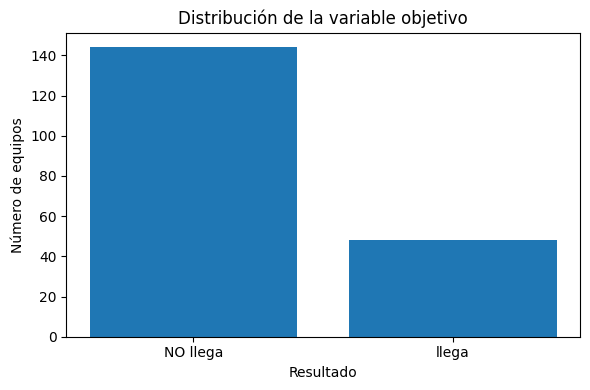

In [ ]:
target = "quarter_finalist"

print("\nDistribución de la variable objetivo:")
print(df_train[target].value_counts())

print("\nDistribución porcentual:")
print(df_train[target].value_counts(normalize=True) * 100)


# Gráfica distribución variable objetivo
target_counts = df_train[target].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["NO llega", "llega"], target_counts.values)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado")
plt.ylabel("Número de equipos")
plt.tight_layout()
plt.show()


Muestra el desbalance de clases: 144 equipos (75%) no llegaron a cuartos y 48 (25%) sí llegaron, que es completamente esperado dado el formato del torneo (8 de 32 pasan a cuartos).

Decidimos no rebalancear los datos distorsionaría esa distribución real y generaría un modelo que sobreestima la probabilidad de clasificar para equipos mediocres. En problemas deportivos, respetar la distribución natural tiene más sentido que forzar un balance artificial. Este desbalance es importante porque los modelos tenderán a predecir "no llega" con más frecuencia, lo que infla la accuracy pero baja el recall.

Validamos cantidad de datos nulos en las diferentes variables.

Faltantes train:


,variable,faltantes_train,pct_faltantes_train
10,squad_total_market_value_eur,32,0.166667


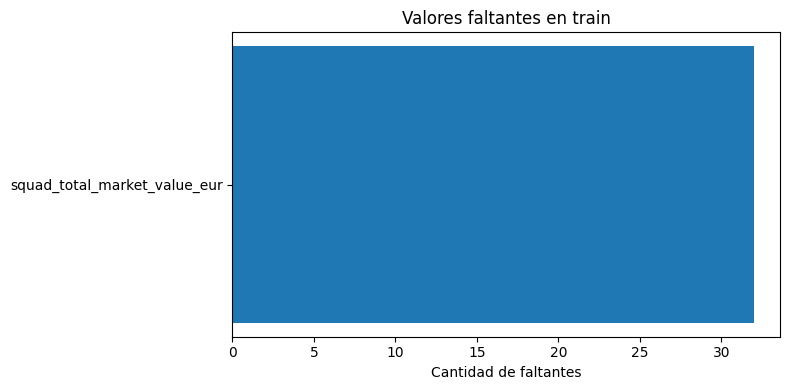

In [ ]:
missing_train = df_train.isnull().sum().reset_index()
missing_train.columns = ["variable", "faltantes_train"]
missing_train["pct_faltantes_train"] = missing_train["faltantes_train"] / len(df_train)
missing_train = missing_train[missing_train["faltantes_train"] > 0].sort_values(
    "faltantes_train", ascending=False
)


print("Faltantes train:")
display(missing_train)


if len(missing_train) > 0:
    plt.figure(figsize=(8, 4))
    plt.barh(missing_train["variable"], missing_train["faltantes_train"])
    plt.title("Valores faltantes en train")
    plt.xlabel("Cantidad de faltantes")
    plt.tight_layout()
    plt.show()


Solo se evidencian varoles nulos en la variable _squad_total_market_value_eur_ especificamente 32 registros, por lo tanto, se procede a generar una imputación, ya que tenemos muy pocas variables y no sería correcto eliminar esas entradas por la información que perderiamos. La decisión siguiente es validar la dispersión de los datos de esa columna para ver si es mejor imputar por la media o la mediana.

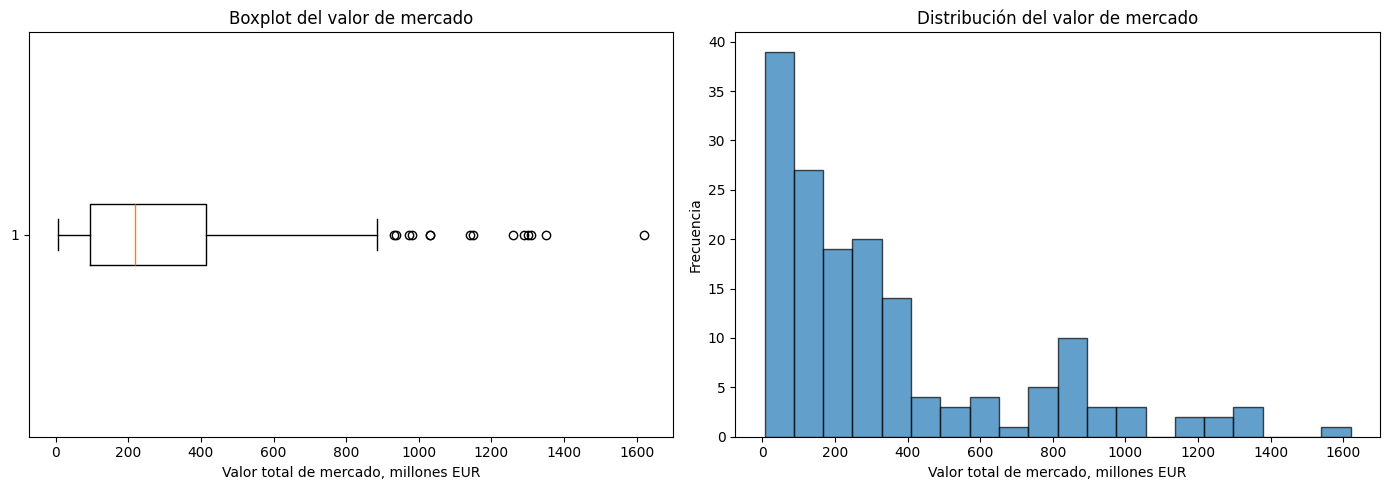

In [ ]:
variable = "squad_total_market_value_eur"

market_value = df_train[variable].dropna() / 1_000_000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].boxplot(
    market_value,
    vert=False
)

axes[0].set_title("Boxplot del valor de mercado")
axes[0].set_xlabel("Valor total de mercado, millones EUR")


axes[1].hist(
    market_value,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

axes[1].set_title("Distribución del valor de mercado")
axes[1].set_xlabel("Valor total de mercado, millones EUR")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

El boxplot muestra claramente múltiples outliers por encima del bigote superior (valores extremos de Europa como España, Brasil, Francia con plantillas >1,000M€). El histograma confirma una distribución con cola pesada a la derecha (sesgo positivo alto). Con lo cual se justifica la decisión de imputar con la mediana en lugar de la media.


Validamos cuales son las variables que tienen más correlación con _quarter_finalist_.

In [ ]:
result_cols = ["winner","finalist","semi_finalist","quarter_finalist"]

num_cols = df_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols_eda = [
    c for c in num_cols
    if c not in result_cols + ["version"]
]

print("Variables numéricas analizadas:")
print(num_cols_eda)

Variables numéricas analizadas:
['is_host', 'goals_scored_last_4y', 'goals_received_last_4y', 'wins_last_4y', 'losses_last_4y', 'draws_last_4y', 'world_cup_titles_before', 'squad_total_market_value_eur', 'fifa_rank_pre_tournament', 'fifa_points_pre_tournament', 'squad_avg_age', 'world_cup_participations_before', 'groups_passed_before', 'round16_before', 'quarterfinals_before', 'semifinals_before', 'finals_before']


,variable,correlacion
0,squad_total_market_value_eur,0.499386
1,quarterfinals_before,0.384019
2,semifinals_before,0.374196
3,world_cup_titles_before,0.372239
4,groups_passed_before,0.372189
5,finals_before,0.365703
6,world_cup_participations_before,0.321651
7,round16_before,0.318113
8,fifa_rank_pre_tournament,-0.307208
9,losses_last_4y,-0.237603


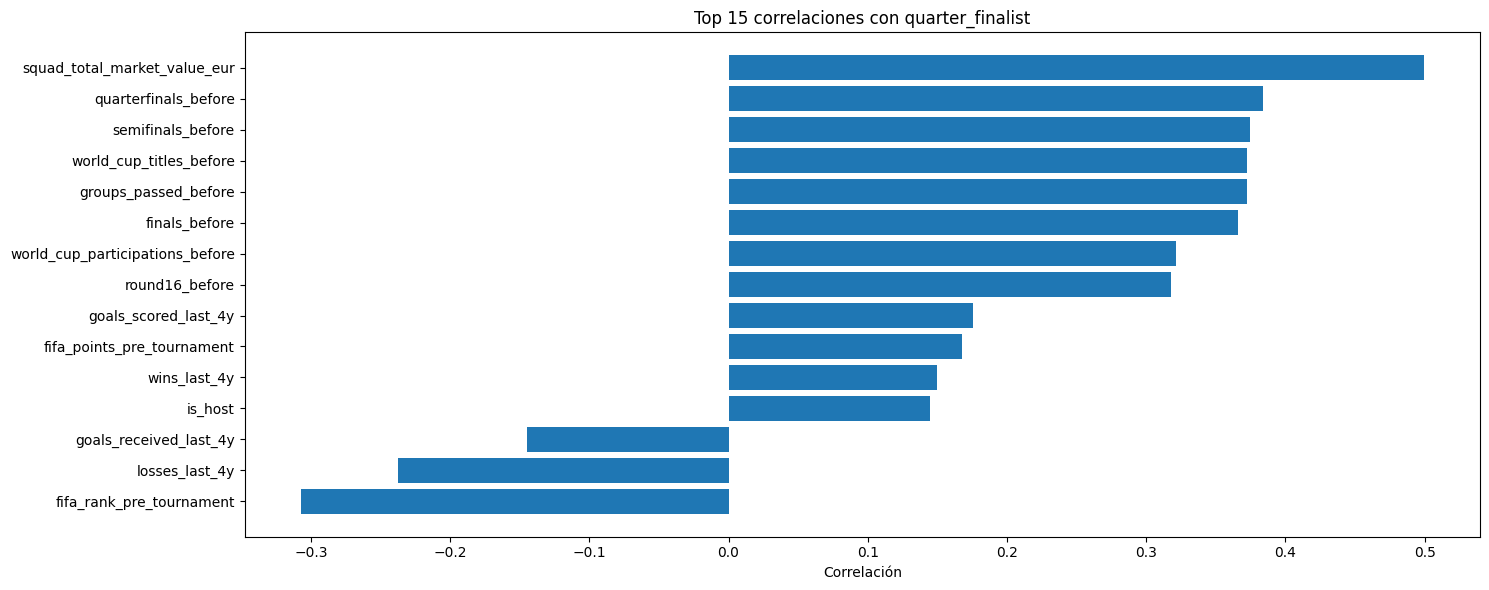

In [ ]:
corr_target = (
    df_train[num_cols_eda + [target]]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(corr_target.reset_index().rename(columns={"index": "variable", target: "correlacion"}))

top_corr = corr_target.head(15).sort_values()

plt.figure(figsize=(15, 6))
plt.barh(top_corr.index, top_corr.values)
plt.title("Top 15 correlaciones con quarter_finalist")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

squad_total_market_value_eur tiene la correlación más alta con la variable objetivo (≈0.50), seguida de quarterfinals_before (≈0.38), semifinals_before (≈0.37), world_cup_titles_before y groups_passed_before. Todas positivas, es decir, equipos con más valor de plantilla e historial en rondas avanzadas por lo generan tienen un mayor avance en el torneo. Por el contrario, goals_received_last_4y, losses_last_4y y fifa_rank_pre_tournament tienen correlación negativa (mayor ranking número = peor posición), lo cual también es coherente. Esta gráfica es una buena base para justificar las features del modelo.

## 4. Preparacion de datos

Se imputan los datos con la mediana, teniendo en cuenta los resultados de las gráficas de dispersión anteriores.

In [ ]:
med_val = df_train['squad_total_market_value_eur'].median()
df_train['squad_total_market_value_eur'] = df_train['squad_total_market_value_eur'].fillna(med_val)
df_test['squad_total_market_value_eur']  = df_test['squad_total_market_value_eur'].fillna(med_val)
print(f'Valor de mercado: nulos imputados con mediana = {med_val/1e6:.1f}M€')

Valor de mercado: nulos imputados con mediana = 217.9M€


Validamos que no aparezcan los valores nulos

In [ ]:
missing_train = df_train.isnull().sum().reset_index()
missing_train.columns = ["variable", "faltantes_train"]
missing_train["pct_faltantes_train"] = missing_train["faltantes_train"] / len(df_train)
missing_train = missing_train[missing_train["faltantes_train"] > 0].sort_values(
    "faltantes_train", ascending=False
)

print("Faltantes train:")
display(missing_train)


if len(missing_train) > 0:
    plt.figure(figsize=(8, 4))
    plt.barh(missing_train["variable"], missing_train["faltantes_train"])
    plt.title("Valores faltantes en train")
    plt.xlabel("Cantidad de faltantes")
    plt.tight_layout()
    plt.show()


Faltantes train:


,variable,faltantes_train,pct_faltantes_train


## 5. Feature engineering y Modelo Predictivo

Se hace feature engineering para robustecer el modelo, en este caso se crean las siguientes variables:


* win_rate: en lugar de usar wins_last_4y como número absoluto, lo conviertes en proporción. Un equipo que ganó 30 de 40 partidos es muy distinto a uno que ganó 30 de 60, aunque el número absoluto sea igual. El modelo no podría detectar esa diferencia sin esta transformación.
* goal_diff_last4y: combina goles anotados y recibidos en una sola variable que mide dominio neto. Un equipo que anota 80 y recibe 20 es muy diferente a uno que anota 80 y recibe 70, pero el modelo necesita esta resta explícita para verlo.
* qf_rate_hist y sf_rate_hist: normalizan el historial por participaciones. Brasil con 17 cuartos en 22 mundiales es menos impresionante que un equipo con 5 cuartos en 6 participaciones. Sin normalizar, los equipos con más participaciones siempre se verían mejor solo por antigüedad.
* log_market_value: la transformación logarítmica reduce el impacto de los outliers extremos (plantillas de +1,000M€) y hace que la distribución sea más simétrica y manejable para los modelos. Sin esto, esos valores extremos dominarían el aprendizaje.
* inv_rank: el ranking FIFA es una escala donde 1 es el mejor, lo cual es contraintuitivo para los modelos que asocian valores altos con más importancia. Al invertirlo, el mejor equipo tiene el valor más alto, haciendo la relación con el target más directa y fácil de aprender.


In [ ]:
def make_features(df):
    df = df.copy()
    df['win_rate']        = df['wins_last_4y'] / (df['wins_last_4y'] + df['losses_last_4y'] + df['draws_last_4y'])
    df['goal_diff_last4y']= df['goals_scored_last_4y'] - df['goals_received_last_4y']
    df['qf_rate_hist']    = df['quarterfinals_before'] / df['world_cup_participations_before'].replace(0,1)
    df['sf_rate_hist']    = df['semifinals_before']    / df['world_cup_participations_before'].replace(0,1)
    df['log_market_value']= np.log1p(df['squad_total_market_value_eur'])
    df['inv_rank']        = 1 / df['fifa_rank_pre_tournament']
    return df

df_train = make_features(df_train)
df_test  = make_features(df_test)

FEATURES = [
    'goals_scored_last_4y','goals_received_last_4y','wins_last_4y','losses_last_4y',
    'world_cup_titles_before','log_market_value','fifa_rank_pre_tournament',
    'fifa_points_pre_tournament','squad_avg_age','world_cup_participations_before',
    'groups_passed_before','round16_before','quarterfinals_before','semifinals_before',
    'finals_before','win_rate','goal_diff_last4y','qf_rate_hist','sf_rate_hist',
    'inv_rank','is_host'
]

X = df_train[FEATURES]
y = df_train['quarter_finalist']
X_test = df_test[FEATURES]

print(f'Features usadas: {len(FEATURES)}')
print(f'Tamaño train: {X.shape}, test: {X_test.shape}')

Features usadas: 21
Tamaño train: (192, 21), test: (48, 21)


Se corren en este caso 2 modelos un Random Forest y una Regresión Logística.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=3, random_state=42)
sc = StandardScaler()
lr = LogisticRegression(C=0.5, max_iter=1000, random_state=42)

models = {
    'Random Forest': rf.fit(X, y),
    'Logistic Regression': lr.fit(sc.fit_transform(X), y),
}


Los hiperparámetros fueron seleccionados siguiendo criterios basados en las características del dataset. Dado que el conjunto de entrenamiento contiene solo 192 observaciones, se priorizó la regularización para evitar sobreajuste: max_depth=6 y min_samples_leaf=3 en Random Forest limitan la complejidad de los árboles, mientras que C=0.5 en Logistic Regression aplica regularización moderada. El número de árboles n_estimators=300 garantiza estabilidad en las predicciones.

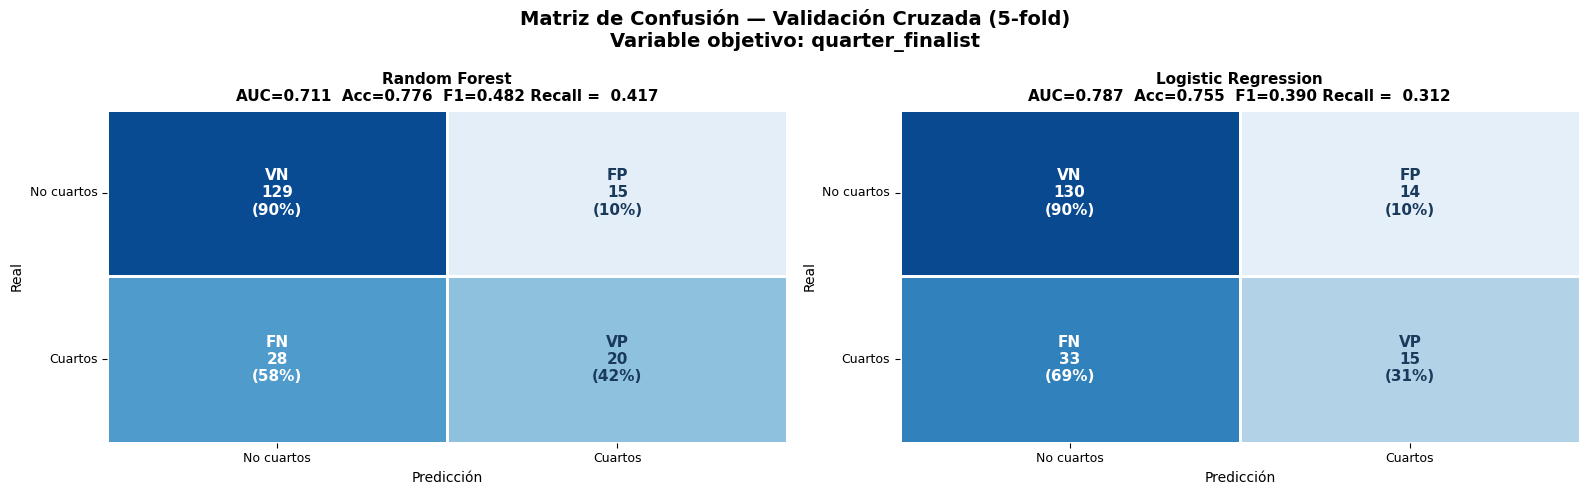

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'Matriz de Confusión — Validación Cruzada (5-fold)\nVariable objetivo: quarter_finalist',
    fontsize=14, fontweight='bold'
)

resultados = {}

for ax, (name, model) in zip(axes, models.items()):

    # Predicciones con validación cruzada
    if name == 'Logistic Regression':
        sc = StandardScaler()
        Xs = sc.fit_transform(X)
        y_pred = cross_val_predict(model, Xs, y, cv=cv)
        y_prob = cross_val_predict(model, Xs, y, cv=cv, method='predict_proba')[:, 1]
    else:
        y_pred = cross_val_predict(model, X, y, cv=cv)
        y_prob = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

    # Métricas
    cm      = confusion_matrix(y, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    auc     = roc_auc_score(y, y_prob)
    rep     = classification_report(y, y_pred, target_names=['No cuartos', 'Cuartos'], output_dict=True)

    # Guardar métricas
    resultados[name] = {
        'AUC-ROC':   auc,
        'Accuracy':  rep['accuracy'],
        'Precision': rep['Cuartos']['precision'],
        'Recall':    rep['Cuartos']['recall'],
        'F1-Score':  rep['Cuartos']['f1-score'],
        'VN': cm[0,0], 'FP': cm[0,1], 'FN': cm[1,0], 'VP': cm[1,1]
    }

    # Visualizar heatmap normalizado con anotaciones absolutas
    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax,
                vmin=0, vmax=1, linewidths=2, linecolor='white', cbar=False)

    etiquetas = [
        [f'VN\n{cm[0,0]}\n({cm_norm[0,0]*100:.0f}%)', f'FP\n{cm[0,1]}\n({cm_norm[0,1]*100:.0f}%)'],
        [f'FN\n{cm[1,0]}\n({cm_norm[1,0]*100:.0f}%)', f'VP\n{cm[1,1]}\n({cm_norm[1,1]*100:.0f}%)']
    ]
    for i in range(2):
        for j in range(2):
            color = 'white' if cm_norm[i, j] > 0.5 else '#1a3a5c'
            ax.text(j + 0.5, i + 0.5, etiquetas[i][j],
                    ha='center', va='center', fontsize=11, fontweight='bold', color=color)

    f1  = rep['Cuartos']['f1-score']
    acc = rep['accuracy']
    Recall = rep['Cuartos']['recall']
    ax.set_title(f'{name}\nAUC={auc:.3f}  Acc={acc:.3f}  F1={f1:.3f} Recall ={Recall:.3f}'  ,
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xticklabels(['No cuartos', 'Cuartos'], fontsize=9)
    ax.set_yticklabels(['No cuartos', 'Cuartos'], fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

Luego de revisar la literatura se recomienda debido a que ambos modelos se pueden complementar, realizar un ensamble para mejorar la predicción, la recomendación es darles proporciones de acuerdo a su AUC, así cada modelo recibe un peso proporcional según su desempeño.

Se determinan los pesos para el ensamble a continuación.

In [ ]:
aucs = {'rf': 0.711, 'lr': 0.787}
total = sum(aucs.values())
w_rf = aucs['rf'] / total
w_lr = aucs['lr'] / total

print(round(w_rf,2))
print(round(w_lr,2))

0.47
0.53


Finalmente se determinan las probabilidades para la data test.

In [ ]:
rf.fit(X, y)
lr.fit(sc.fit_transform(X), y)

p_rf = rf.predict_proba(X_test)[:,1]
p_lr = lr.predict_proba(sc.transform(X_test))[:,1]
prob_ensemble = p_rf*0.47 + p_lr*0.53

pred = df_test[['team','continent']].copy()
pred['prob_rf']       = p_rf
pred['prob_lr']       = p_lr
pred['prob_ensemble'] = prob_ensemble
pred = pred.sort_values('prob_ensemble', ascending=False).reset_index(drop=True)
pred.index += 1

print('Top 20 favoritos para cuartos de final 2026:')
print(pred[['team','continent','prob_ensemble']].head(20).to_string())

Top 20 favoritos para cuartos de final 2026:
             team      continent  prob_ensemble
1       Argentina  South America       0.704565
2         Germany         Europe       0.650013
3         England         Europe       0.594347
4          Brazil  South America       0.592896
5          France         Europe       0.552894
6           Spain         Europe       0.542774
7         Morocco         Africa       0.505497
8        Portugal         Europe       0.477495
9         Uruguay  South America       0.457639
10    Netherlands         Europe       0.413093
11         Mexico  North America       0.409364
12  United States  North America       0.408300
13        Belgium         Europe       0.339913
14        Senegal         Africa       0.331833
15         Norway         Europe       0.290942
16        Ecuador  South America       0.290846
17         Sweden         Europe       0.288380
18    Ivory Coast         Africa       0.283359
19          Japan           Asia       0.25

# 6. Calcular SHAP values

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_test)

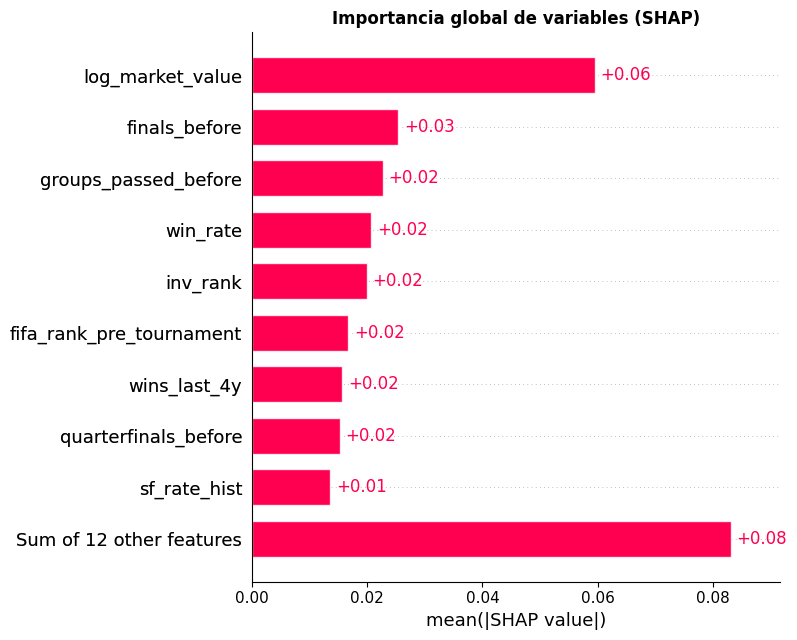

In [ ]:
shap.plots.bar(shap_values[:, :, 1], show=False)
plt.title("Importancia global de variables (SHAP)", fontweight="bold")
plt.tight_layout()
plt.show()

## Interpretación de importancia global SHAP

La gráfica de importancia global SHAP muestra cuáles variables tienen mayor influencia en las predicciones del modelo para estimar la probabilidad de que una selección alcance los cuartos de final de la Copa Mundial.

La variable más importante fue `log_market_value`, lo que indica que el valor de mercado del equipo tiene una fuerte relación con el desempeño esperado en el torneo. Esto sugiere que selecciones con plantillas más valiosas tienden a tener mayores probabilidades de avanzar a fases finales.

También se observa una alta relevancia de variables históricas como `finals_before`, `groups_passed_before` y `quarterfinals_before`, evidenciando que la experiencia previa en competencias internacionales influye significativamente en el modelo.

Por otra parte, variables asociadas al rendimiento reciente como `win_rate` y `wins_last_4y` muestran que el estado competitivo actual del equipo también es determinante en las predicciones.

En conjunto, el modelo combina información histórica, desempeño reciente y calidad de plantilla para estimar la probabilidad de clasificación a cuartos de final.

## Plot (Beeswarm)

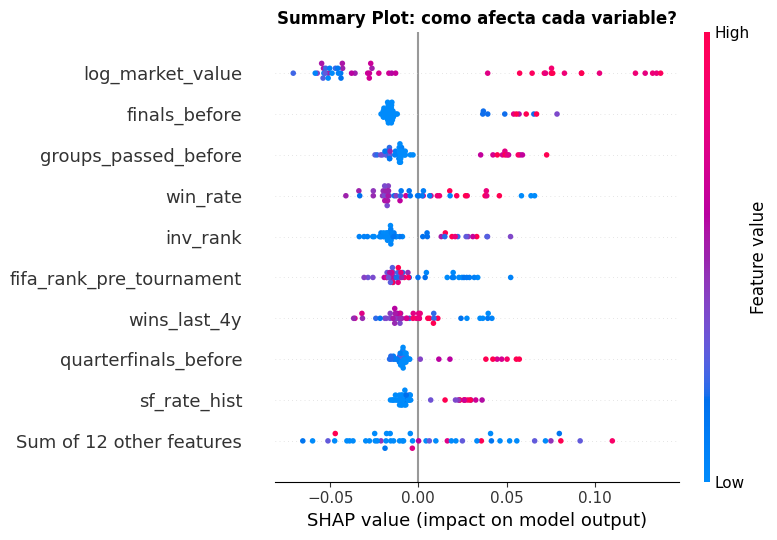

In [ ]:
shap.plots.beeswarm(shap_values[:, :, 1], show=False)
plt.title("Summary Plot: como afecta cada variable?", fontweight="bold")
plt.tight_layout()
plt.show()

## Interpretación del SHAP Summary Plot

El SHAP Summary Plot permite analizar cómo cada variable afecta las predicciones individuales del modelo. En el eje horizontal se representan los valores SHAP, donde valores positivos aumentan la probabilidad de que una selección alcance los cuartos de final, mientras que valores negativos disminuyen dicha probabilidad.

La variable `log_market_value` presenta el mayor impacto en el modelo. Se observa que valores altos de esta variable (representados en color rosado) generan contribuciones positivas importantes, indicando que selecciones con mayor valor de mercado tienen una mayor probabilidad de avanzar en el torneo.

Las variables históricas como `finals_before`, `groups_passed_before` y `quarterfinals_before` también muestran una influencia positiva significativa. Esto evidencia que la experiencia histórica en competiciones internacionales es un factor relevante dentro de las decisiones del modelo.

Por otro lado, variables relacionadas con el desempeño reciente como `win_rate` y `wins_last_4y` muestran que equipos con mejores resultados en los años previos al torneo tienden a aumentar la probabilidad de clasificación.

Finalmente, el gráfico evidencia que el modelo combina variables de calidad actual, experiencia histórica y rendimiento reciente para construir sus predicciones, mostrando un comportamiento coherente y consistente desde el punto de vista interpretativo.

## 6. Conclusiones

 - **Argentina** es la gran favorita (70.4%) — respaldada por el título 2022, ranking #3 y alto valor de plantilla.
- Las variables más predictivas son: **valor de mercado**, **historial en rondas avanzadas** y **ranking FIFA**.
- El mejor modelo individual fue **Logistic Regression** (AUC = 0.787), indicando buena capacidad discriminatoria.
- **Limitación:** el dataset tiene solo 192 observaciones en 6 torneos. Las probabilidades son estimaciones, no certezas.
-  El desbalance de clases (75%-25%) limita el recall — el modelo detecta mejor a los equipos que no clasifican que a los que sí lo hacen
- Los equipos europeos (Francia, España, Inglaterra, Alemania, Portugal) dominan el top 10, lo que es coherente con la tasa histórica de clasificación de Europa. Marruecos es la gran sorpresa africana, impulsado por su histórico semifinal en Qatar 2022 que elevó significativamente sus variables de historial.

## 7. Uso de IA

El uso de IA aceleró significativamente las tareas técnicas (escritura de código, generación de gráficas, estructuración del notebook), pero todas las decisiones analíticas clave fueron revisadas y validadas manualmente:

*La elección de la mediana sobre la media para imputar nulos fue confirmada tras analizar la distribución.

*Los pesos del ensemble se ajustaron con criterio propio.

*La interpretación de los resultados fue un análisis propio.

*La IA funcionó como un asistente técnico, no como tomadora de decisiones.

En conclusión, el juicio analítico, la comprensión del dominio y la validación de los resultados fueron responsabilidad de los estudiantes.